# Accessing and Plotting Data from Hanks Lab NWB File

This notebook demonstrates how to access and visualize behavioral data stored in an NWB file generated by the Hanks Lab NWB conversion pipeline.

Example file: **ToneCatDelayResp** protocol (auditory working-memory delayed response), subject **400**, session **119247**.

Behavior is recorded by a **Bpod** state machine and stored with `ndx-structured-behavior`. All timestamps are on the **Doric fiber-photometry clock** (seconds from the start of the Doric recording), so behavioral events can be aligned directly with the fiber-photometry series in the same file.

## Load the NWB file

This section demonstrates how to access an NWB file using `pynwb.NWBHDF5IO`.

In [1]:
from pynwb import NWBHDF5IO

nwbfile_path = "../../../nwb_output/sub-400_ses-119247.nwb"

io = NWBHDF5IO(nwbfile_path, "r")
nwbfile = io.read()

## Session and subject metadata

Basic session info and per-subject metadata (date of birth, sex, strain) sourced from `Subj Info.txt`.

In [2]:
print("Session ID:        ", nwbfile.session_id)
print("Session start:     ", nwbfile.session_start_time)
print("Institution:       ", nwbfile.institution)
print("Lab:               ", nwbfile.lab)
print("Experimenter:      ", nwbfile.experimenter)
print()
sub = nwbfile.subject
print("Subject ID:        ", sub.subject_id)
print("Species:           ", sub.species)
print("Strain:            ", sub.strain)
print("Sex:               ", sub.sex)
print("Date of birth:     ", sub.date_of_birth.date())
print("Weight:            ", sub.weight)
print()
print("Session description:")
print(nwbfile.session_description)

Session ID:         119247
Session start:      2025-10-02 11:48:47-07:00
Institution:        University of California, Davis
Lab:                Hanks
Experimenter:       ('Stevenson, Tanner',)

Subject ID:         400
Species:            Rattus norvegicus
Strain:             Long Evans
Sex:                M
Date of birth:      2024-03-19
Weight:             530 g

Session description:
This session contains fiber photometry and behavioral data from a rat performing an auditory working memory delay response task (ToneCatDelayResp). On each trial, a center port LED cue signals trial availability; the rat initiates by poking the center port and maintaining fixation, hears 1 auditory tone during a stimulus window, and after a delay period must poke the correct side port based on the remembered tone category to receive a water reward. Behavioral events are controlled and recorded by Bpod. Fluorescence signals are acquired simultaneously from up to four brain regions using a Doric system wit

## Accessing the task metadata

The task-related general metadata is stored in a `Task` object which can be accessed as `nwbfile.lab_meta_data["task"]`.

The `EventTypesTable` is a column-based table to store the type of events that occur during the task (e.g. port poke from the animal), one type per row. This table can be accessed as `nwbfile.lab_meta_data["task"].event_types`.

Bpod reports port contacts under names that fuse the port and the edge — `Port3In`, `Port3Out`. Here the type table names only the **port**, and the edge lives in the `value` column of each occurrence row, so `Port3In` is stored as `event_name="Port3"`, `value="In"`. The raw Bpod name is always recoverable as `event_name + value`.

For this rig the three ports are: **Port1 = left**, **Port2 = center**, **Port3 = right**.

In [3]:
nwbfile.lab_meta_data["task"].event_types[:]

,event_name
id,
0,Port1
1,Port2
2,Port3


The `ActionTypesTable` is a column-based table to store the type of actions that occur during the task (e.g. sound output from the acquisition system), one type per row.
This table can be accessed as `nwbfile.lab_meta_data["task"].action_types`.

Here the actions are the machine-triggered Bpod outputs: the `BNC1` TTL line that is also recorded by the Doric system (used to synchronize the two clocks), the global timers that implement the stimulus/delay windows, `Condition1`, and `Tup` (state timer expiry).

The same name/value split applies: Bpod's `BNC1High` / `BNC1Low` become `action_name="BNC1"` with `value` `"On"` / `"Off"`, and `GlobalTimer2_End` becomes `action_name="GlobalTimer2"`, `value="End"`.

All six action types are registered in every session even when a session never fires one of them, so the registry is identical across files and can be compared directly.

In [4]:
nwbfile.lab_meta_data["task"].action_types[:]

,action_name
id,
0,BNC1
1,Condition1
2,GlobalTimer1
3,GlobalTimer2
4,GlobalTimer3
5,Tup


The `StateTypesTable` is a column-based table to store the type of states that occur during the task (e.g. while the animal is waiting for reward), one type per row.
This table can be accessed as `nwbfile.lab_meta_data["task"].state_types`.

The `GenerateTrialBit1`–`GenerateTrialBit15` states present in the raw Bpod data are **not** stored: they encode the trial number as a 15-bit TTL word for Doric synchronization rather than a behavioral state.

In [5]:
nwbfile.lab_meta_data["task"].state_types[:]

,state_name
id,
0,SyncBit
1,ITI
2,WaitForCenterPoke
3,StartStim
4,WaitForSync
5,StartStimulusTimer
6,Stimulus
7,StartStimLCBTimer
8,StimLCB


## Accessing the behavioral data

The `TaskRecording` object stores the data for events, states, and actions that occured during the task. The `TaskRecording` is added as acquisition which can be accessed as `nwbfile.acquisition["task_recording"]`.

### Events

The `EventsTable` is a column-based table to store the information about the events (e.g. poke times), one event per row. This table can be accessed as `nwbfile.acquisition["task_recording"].events`.

Events are **animal-triggered** port contacts. Merging against the `EventTypesTable` resolves the `event_type` foreign key to the port name; pairing that with the `value` column (`"In"` / `"Out"`) gives the original Bpod name — the row below with `event_name="Port3"` and `value="In"` is Bpod's `Port3In`.

In [6]:
import pandas as pd

pd.merge(
    nwbfile.acquisition["task_recording"].events[:],
    nwbfile.lab_meta_data["task"].event_types[:],
    left_on="event_type",
    right_on="id",
)

,timestamp,event_type,value,event_name
0,14.758558,2,In,Port3
1,14.780058,2,Out,Port3
2,20.036258,0,In,Port1
3,20.070858,0,Out,Port1
4,20.787058,0,In,Port1
...,...,...,...,...
6797,2257.521882,2,Out,Port3
6798,2257.626282,2,In,Port3
6799,2258.110382,2,Out,Port3
6800,2464.426582,1,In,Port2


### States

The `StatesTable` is a column-based table to store the information about the states (e.g. the duration while nose is in center port). This table can be accessed as `nwbfile.acquisition["task_recording"].states`.

Each row is one **occurrence** of a state, with `start_time` and `stop_time` in Doric-clock seconds.

In [7]:
pd.merge(
    nwbfile.acquisition["task_recording"].states[:],
    nwbfile.lab_meta_data["task"].state_types[:],
    left_on="state_type",
    right_on="id",
)

,start_time,stop_time,state_type,state_name
0,12.535158,12.536158,0,SyncBit
1,12.551158,17.551158,1,ITI
2,17.551158,239.875958,2,WaitForCenterPoke
3,239.875958,239.876058,3,StartStim
4,239.876058,239.885358,4,WaitForSync
...,...,...,...,...
1841,3983.171162,3983.172162,0,SyncBit
1842,3983.187162,3986.346162,1,ITI
1843,3986.346162,4286.346162,2,WaitForCenterPoke
1844,4286.346162,4286.346262,20,NoCenterPoke


### Actions

The `ActionsTable` stores the **machine-triggered** outputs, one per row, accessible as `nwbfile.acquisition["task_recording"].actions`. As with events, the `action_name` from the type table plus the `value` column reconstructs the raw Bpod name: `BNC1` + `On` is `BNC1High`, `GlobalTimer1` + `End` is `GlobalTimer1_End`, `Tup` + `Expired` is `Tup`.

In [8]:
pd.merge(
    nwbfile.acquisition["task_recording"].actions[:],
    nwbfile.lab_meta_data["task"].action_types[:],
    left_on="action_type",
    right_on="id",
)

,timestamp,action_type,value,action_name
0,12.536158,5,Expired,Tup
1,12.537158,5,Expired,Tup
2,12.538158,5,Expired,Tup
3,12.539158,5,Expired,Tup
4,12.540158,5,Expired,Tup
...,...,...,...,...
4418,3983.187162,5,Expired,Tup
4419,3986.346162,5,Expired,Tup
4420,4286.346162,5,Expired,Tup
4421,4286.346262,5,Expired,Tup


### Plot the events, actions, and states

The ``plot_events``, ``plot_actions``, and ``plot_states`` functions can consume both the raw table as well as a subset of the table as a pandas DataFrame created through slicing, e.g., via ``events[:100]`` will plot only the first 100 rows from the events table.

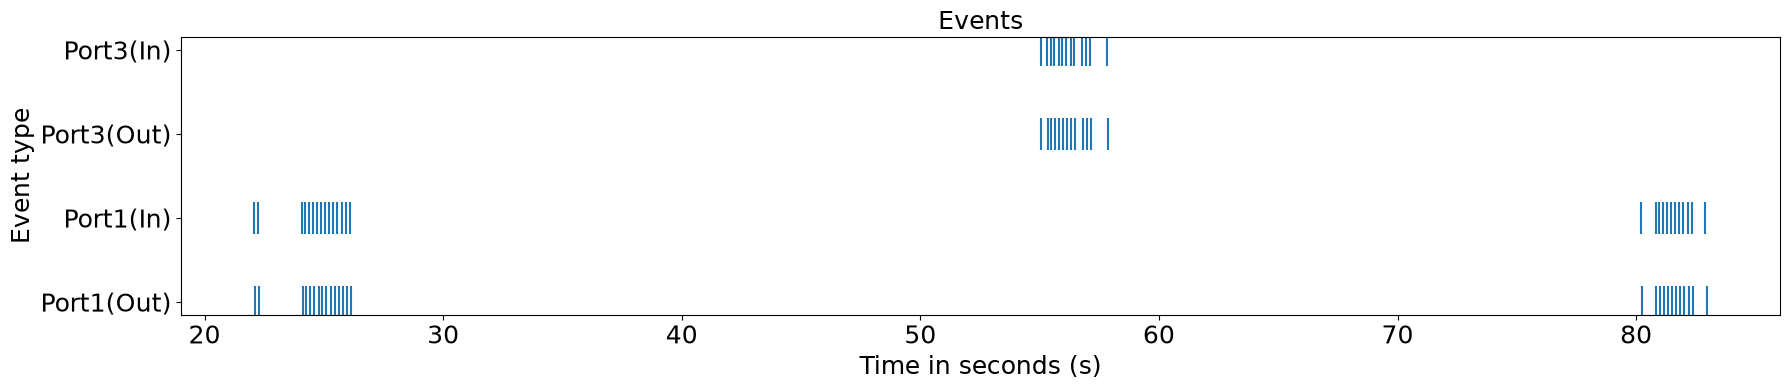

In [9]:
from matplotlib import pyplot as plt
from ndx_structured_behavior.plot import (
    plot_actions,
    plot_events,
    plot_states,
    plot_trials,
)

# Get the events from file
events = nwbfile.get_acquisition("task_recording").events
event_types = nwbfile.get_lab_meta_data("task").event_types

# Plot the data
fig = plot_events(
    events=events[20:100],
    event_types=event_types,
    show_event_values=True,
    figsize=(18, 4),
    marker_size=500,
)
plt.title("Events", fontsize=18)
plt.tight_layout()
plt.show()

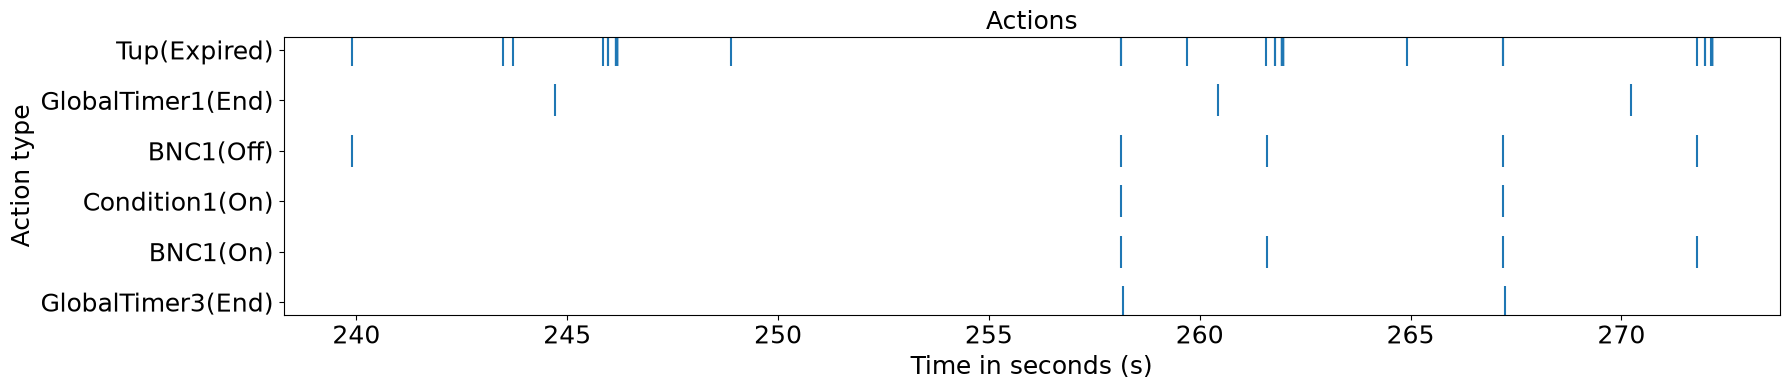

In [10]:
# Get the actions from file
actions = nwbfile.get_acquisition("task_recording").actions
action_types = nwbfile.get_lab_meta_data("task").action_types

# Plot the data
fig = plot_actions(
    actions=actions[20:100],
    action_types=action_types,
    figsize=(18, 4),
    marker_size=500,
)
plt.title("Actions", fontsize=18)
plt.tight_layout()
plt.show()

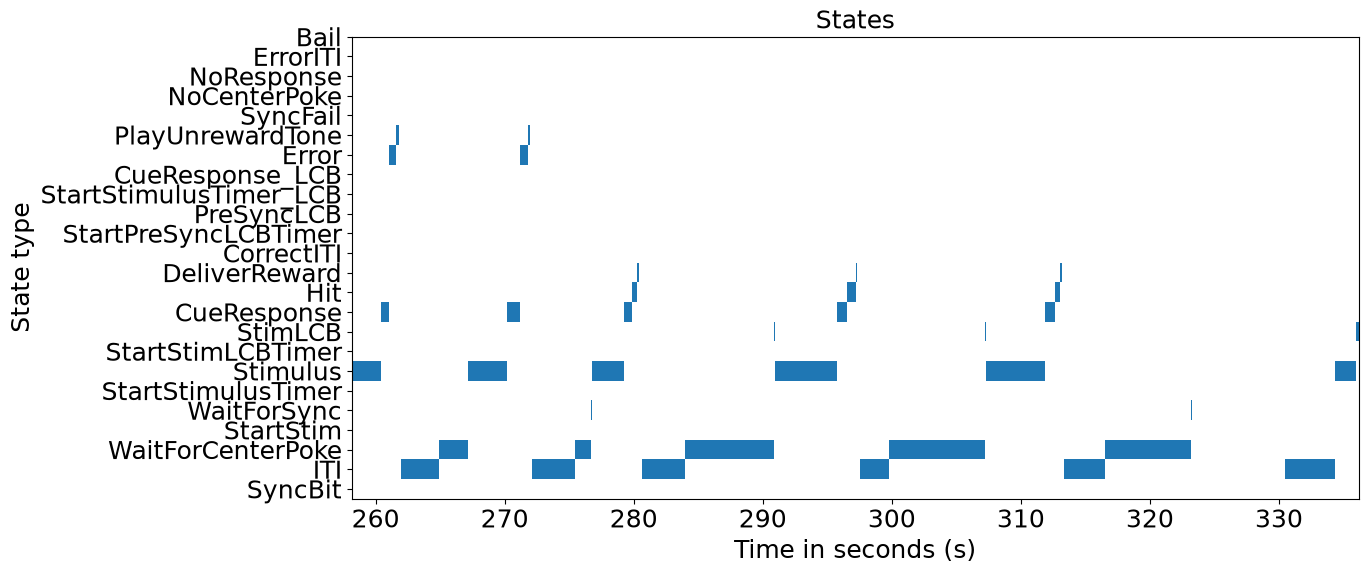

In [11]:
# Get the states from file
states = nwbfile.get_acquisition("task_recording").states
state_types = nwbfile.get_lab_meta_data("task").state_types

# Plot the data
plot_states(
    figsize=(13, 6),
    states=states[20:100],
    state_types=state_types,
    marker_size=500,
)
plt.title("States", fontsize=18)
plt.show()

## Trials

`nwbfile.trials` is a `TrialsTable` with one row per trial. Besides `start_time` / `stop_time` it carries three `DynamicTableRegion` columns — `states`, `events`, `actions` — each holding the row indices of that trial's entries in the tables above, plus every per-trial column from `sess_data_119247.pkl`.

In [12]:
trials = nwbfile.trials
trials[:].head()

,start_time,stop_time,startstage,rigid,hit,bail,reward,choice,n_tones,stim_dur,...,next_tone_info,next_correct_port,incongruent,switch,stay,next_switch,next_stay,states,events,actions
id,,,,,,,,,,,,,,,,,,,,,
0,12.535158,246.164554,7,101,True,False,20,right,1,4.819902,...,[low],left,False,False,False,False,True,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,246.164554,261.955138,7,101,False,False,0,right,1,2.288515,...,[low],left,False,False,True,False,True,"[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2...","[194, 195, 196, 197, 198, 199, 200, 201, 202, ...","[28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 3..."
2,261.955138,272.134424,7,101,False,False,0,right,1,3.026336,...,[high],right,False,False,True,False,True,"[31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]","[296, 297, 298, 299, 300, 301, 302, 303, 304, ...","[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6..."
3,272.134424,280.609720,7,101,True,False,20,right,1,2.550231,...,[low],left,False,False,True,True,False,"[42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]","[306, 307, 308, 309, 310, 311, 312, 313, 314]","[87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 9..."
4,280.609720,297.504370,7,101,True,False,20,left,1,4.853979,...,[low],left,False,True,False,False,True,"[53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 6...","[315, 316, 317, 318, 319, 320, 321, 322, 323, ...","[113, 114, 115, 116, 117, 118, 119, 120, 121, ..."


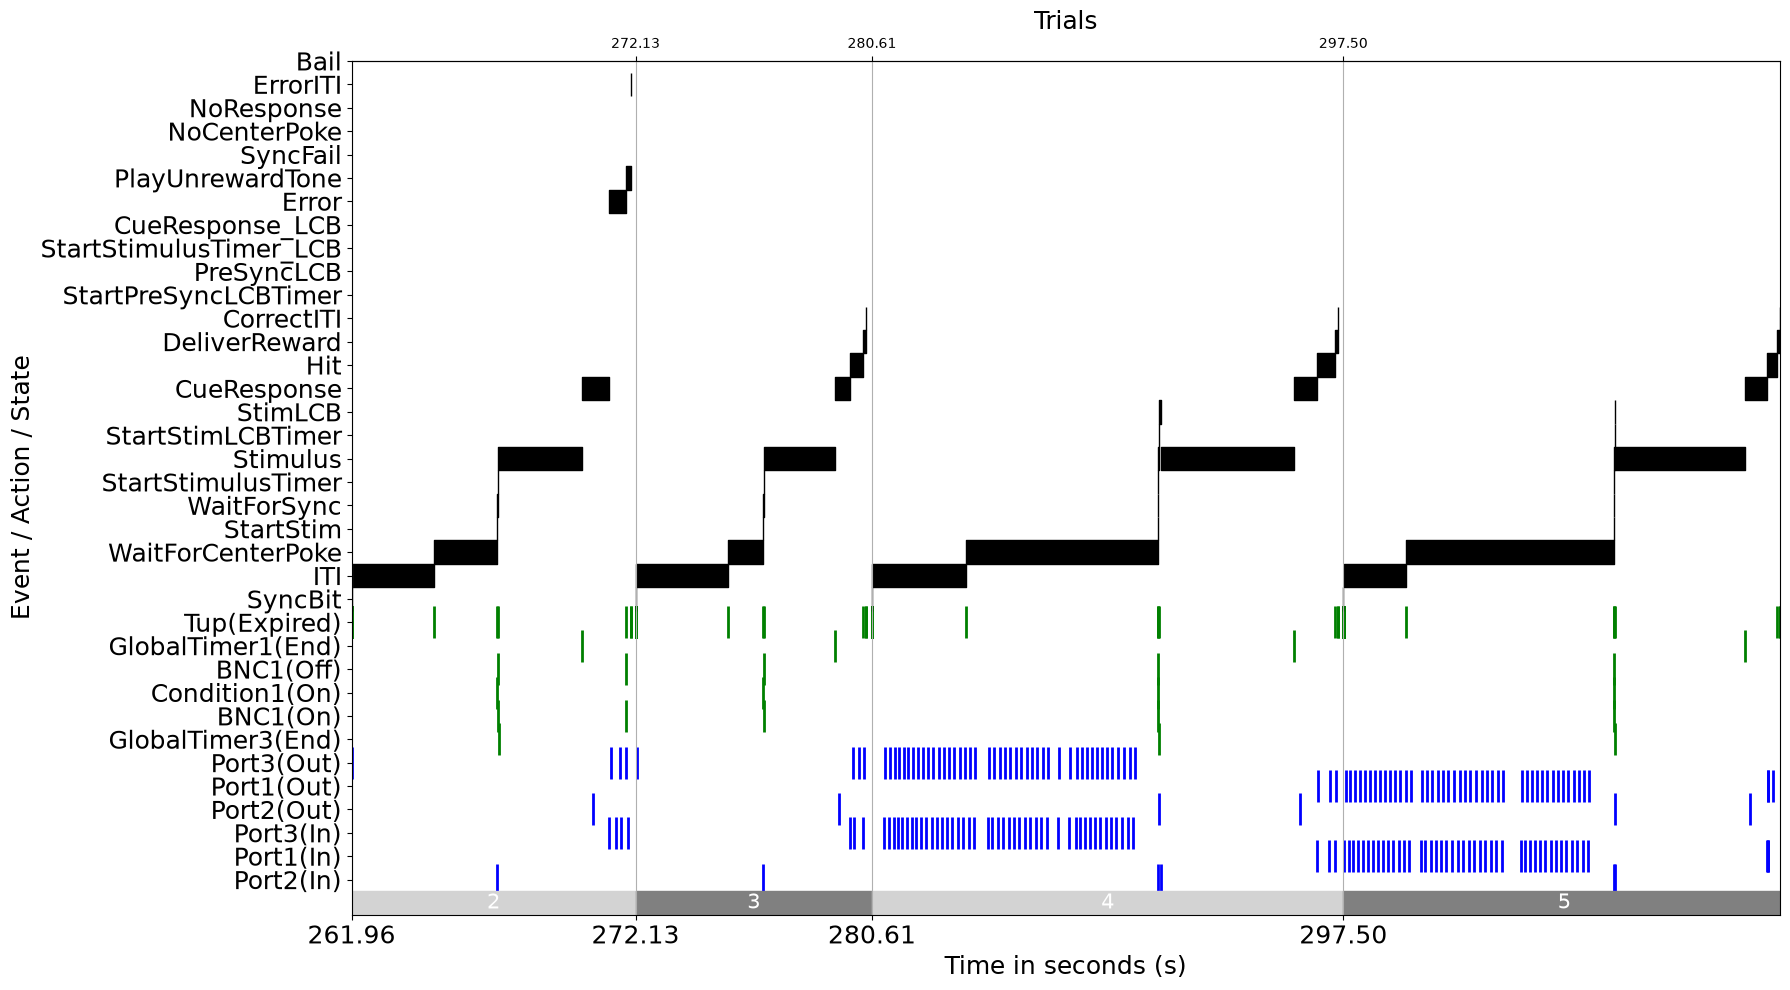

In [13]:
# Plot trial 2 - 5
from ndx_structured_behavior.plot import plot_trials

plot_trials(
    trials=trials[2:6],
    states=states, state_types=state_types,
    actions=actions, action_types=action_types,
    events=events, event_types=event_types,
    figsize=None,
    fontsize=18,
    rectangle_height=1,
    marker_size=500)
plt.title("Trials", fontsize=18)
plt.tight_layout()
plt.show()

### What the trials table holds

Besides `start_time` / `stop_time` and the three `DynamicTableRegion` links, every per-trial column
from `sess_data_119247.pkl` is carried over, each with the description configured in
`bpod_behavior_columns.yaml`. Rather than scroll the full frame, the table below lists what is
available: storage type, how many trials have a value, an example, and what the column means.

In [14]:
import numpy as np

trials_df = nwbfile.trials.to_dataframe()

# The three DynamicTableRegion columns link out to the states/events/actions tables
# rather than holding trial data themselves.
LINK_COLUMNS = ("states", "events", "actions")


def column_description(name):
    """Real description for a column.

    Ragged columns are returned as a VectorIndex, whose own description is the
    boilerplate "Index for VectorData '<name>'" — the description worth reading
    lives on the VectorData it targets.
    """
    column = nwbfile.trials[name]
    return column.target.description if hasattr(column, "target") else column.description


def example_value(name, values):
    if name in LINK_COLUMNS:
        return f"{len(values.iloc[0])} linked rows"
    non_null = values.dropna()
    if non_null.empty:
        return ""
    first = non_null.iloc[0]
    if isinstance(first, (list, np.ndarray)):
        # skip leading empties (e.g. prev_tone_info on the first trial)
        non_empty = [v for v in non_null if len(v)]
        if not non_empty:
            return "[]"
        first = non_empty[0]
        return "[" + ", ".join(f"{v:.4g}" if isinstance(v, (float, np.floating)) else str(v)
                               for v in list(first)[:2]) + "]"
    return f"{first:.4g}" if isinstance(first, (float, np.floating)) else str(first)


def storage_kind(name, values):
    if name in LINK_COLUMNS:
        return "link"
    non_null = values.dropna()
    if non_null.empty:
        return "empty"
    first = non_null.iloc[0]
    if isinstance(first, (list, np.ndarray)):
        return "ragged"
    return type(first).__name__.replace("64", "").replace("_", "")


columns = pd.DataFrame([
    dict(column=name,
         type=storage_kind(name, trials_df[name]),
         filled=f"{trials_df[name].notna().sum()}/{len(trials_df)}",
         example=example_value(name, trials_df[name]),
         description=column_description(name))
    for name in nwbfile.trials.colnames
])

pd.set_option("display.max_rows", None, "display.max_colwidth", 60, "display.width", 200)
columns

,column,type,filled,example,description
0,start_time,float,165/165,12.54,"Start time of epoch, in seconds"
1,stop_time,float,165/165,246.2,"Stop time of epoch, in seconds"
2,startstage,int,165/165,7,Training stage number at session start.
3,rigid,int,165/165,101,Rig ID where the session was run.
4,hit,bool,165/165,True,True if the animal made a valid response within the resp...
5,bail,bool,165/165,False,True if the animal withdrew from center port before the ...
6,reward,int,165/165,20,Reward volume delivered (µL); 0 if unrewarded.
7,choice,str,165/165,right,"Side the animal chose: 'left', 'right', or 'none'."
8,n_tones,int,165/165,1,Number of tones presented during the stimulus window.
9,stim_dur,float,165/165,4.82,Stimulus window duration (seconds).


In [15]:
# ── Session summary ──────────────────────────────────────────────────────────
print(f"Trials            : {len(trials_df)}")
print(f"Columns           : {len(nwbfile.trials.colnames)} "
      f"({', '.join(f'{k} {v}' for k, v in columns['type'].value_counts().items())})")
print(f"Session duration  : {(trials_df['stop_time'].max() - trials_df['start_time'].min()) / 60:.1f} min")
print()

if "trial_started" in trials_df:
    started = trials_df[trials_df["trial_started"] == True]
    print(f"Trials started    : {len(started)} / {len(trials_df)}")
else:
    started = trials_df

# Outcome columns differ by protocol, so report whichever this session carries.
for name, label in [("hit", "Hit rate"), ("bail", "Bail rate"), ("viol", "Violation rate"),
                    ("rewarded", "Rewarded"), ("chose_left", "Chose left"),
                    ("chose_right", "Chose right"), ("switch", "Switched"),
                    ("chose_high", "Chose high-probability port")]:
    if name in started.columns:
        rate = pd.to_numeric(started[name], errors="coerce")
        if rate.notna().any():
            print(f"{label:<18}: {rate.mean():.1%}")

# Trial-level timing, useful for sanity-checking the Doric-clock conversion
print()
print(f"First trial start : {trials_df['start_time'].iloc[0]:.3f} s (Doric clock)")
print(f"Last trial stop   : {trials_df['stop_time'].iloc[-1]:.3f} s")
print(f"Median trial      : {(trials_df['stop_time'] - trials_df['start_time']).median():.2f} s")

Trials            : 165
Columns           : 49 (float 14, bool 12, str 8, ragged 8, int 4, link 3)
Session duration  : 71.2 min

Trials started    : 158 / 165
Hit rate          : 65.2%
Bail rate         : 9.5%
Rewarded          : 65.2%
Chose left        : 45.6%
Chose right       : 44.9%
Switched          : 36.1%

First trial start : 12.535 s (Doric clock)
Last trial stop   : 4286.541 s
Median trial      : 11.63 s


## Compute and plot the state transition matrix

Here we compute the state transition matrix for all states throughout the experiment. However, simply by subsetting the StatesTable we can also create the transition matrix for any subset of state transitions, e.g., by selecting only the states from a subset of trials based on the TrialsTable.

In [16]:
from ndx_structured_behavior.plot import compute_state_transition_matrix

# Compute the transition count and probability matrix
state_transition_count_df, state_transition_probability_df = compute_state_transition_matrix(
    states=states, state_types=state_types
)

display(state_transition_count_df)
# display(state_transition_probability_df)

to,SyncBit,ITI,WaitForCenterPoke,StartStim,WaitForSync,StartStimulusTimer,Stimulus,StartStimLCBTimer,StimLCB,CueResponse,...,PreSyncLCB,StartStimulusTimer_LCB,CueResponse_LCB,Error,PlayUnrewardTone,SyncFail,NoCenterPoke,NoResponse,ErrorITI,Bail
from,,,,,,,,,,,,,,,,,,,,,
SyncBit,0,165,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ITI,0,0,165,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WaitForCenterPoke,0,0,0,159,0,0,0,0,0,0,...,0,0,0,0,0,0,6,0,0,0
StartStim,0,0,0,0,159,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WaitForSync,0,0,0,0,0,158,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
StartStimulusTimer,0,0,0,0,0,0,158,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Stimulus,0,0,0,0,0,0,0,44,0,142,...,0,0,0,0,0,0,0,0,0,0
StartStimLCBTimer,0,0,0,0,0,0,0,0,44,0,...,0,0,0,0,0,0,0,0,0,0
StimLCB,0,0,0,0,0,0,28,0,0,0,...,0,0,1,0,0,0,0,0,0,15


### State transition graph

The transition probabilities above are easier to read as a directed graph. Node colour marks the role of each state in the trial, edge width and opacity scale with transition probability, and only transitions with `p >= 0.25` are labelled so the dominant path stays readable.

The three timer-arming states (`StartStim`, `StartStimulusTimer`, `StartStimLCBTimer`) are **bridged out** rather than deleted — see the comment in the cell below for why deleting them outright inverts the meaning of the graph.

The main loop then reads clockwise from the green trial-start node:

`SyncBit -> ITI -> WaitForCenterPoke -> WaitForSync -> Stimulus -> CueResponse -> Hit -> DeliverReward -> CorrectITI` and back to `SyncBit`.

The branches off it are the failure modes: `NoCenterPoke` (4% of trials, the rat never pokes), `Bail` (withdrawal during the stimulus, via `StimLCB`), and the error path `Error -> PlayUnrewardTone -> ErrorITI`. All of them rejoin at the trial start.

Bridged out : ['StartStim', 'StartStimLCBTimer', 'StartStimulusTimer']
Remaining   : ['Bail', 'CorrectITI', 'CueResponse', 'CueResponse_LCB', 'DeliverReward', 'Error', 'ErrorITI', 'Hit', 'ITI', 'NoCenterPoke', 'PlayUnrewardTone', 'StimLCB', 'Stimulus', 'SyncBit', 'SyncFail', 'WaitForCenterPoke', 'WaitForSync']


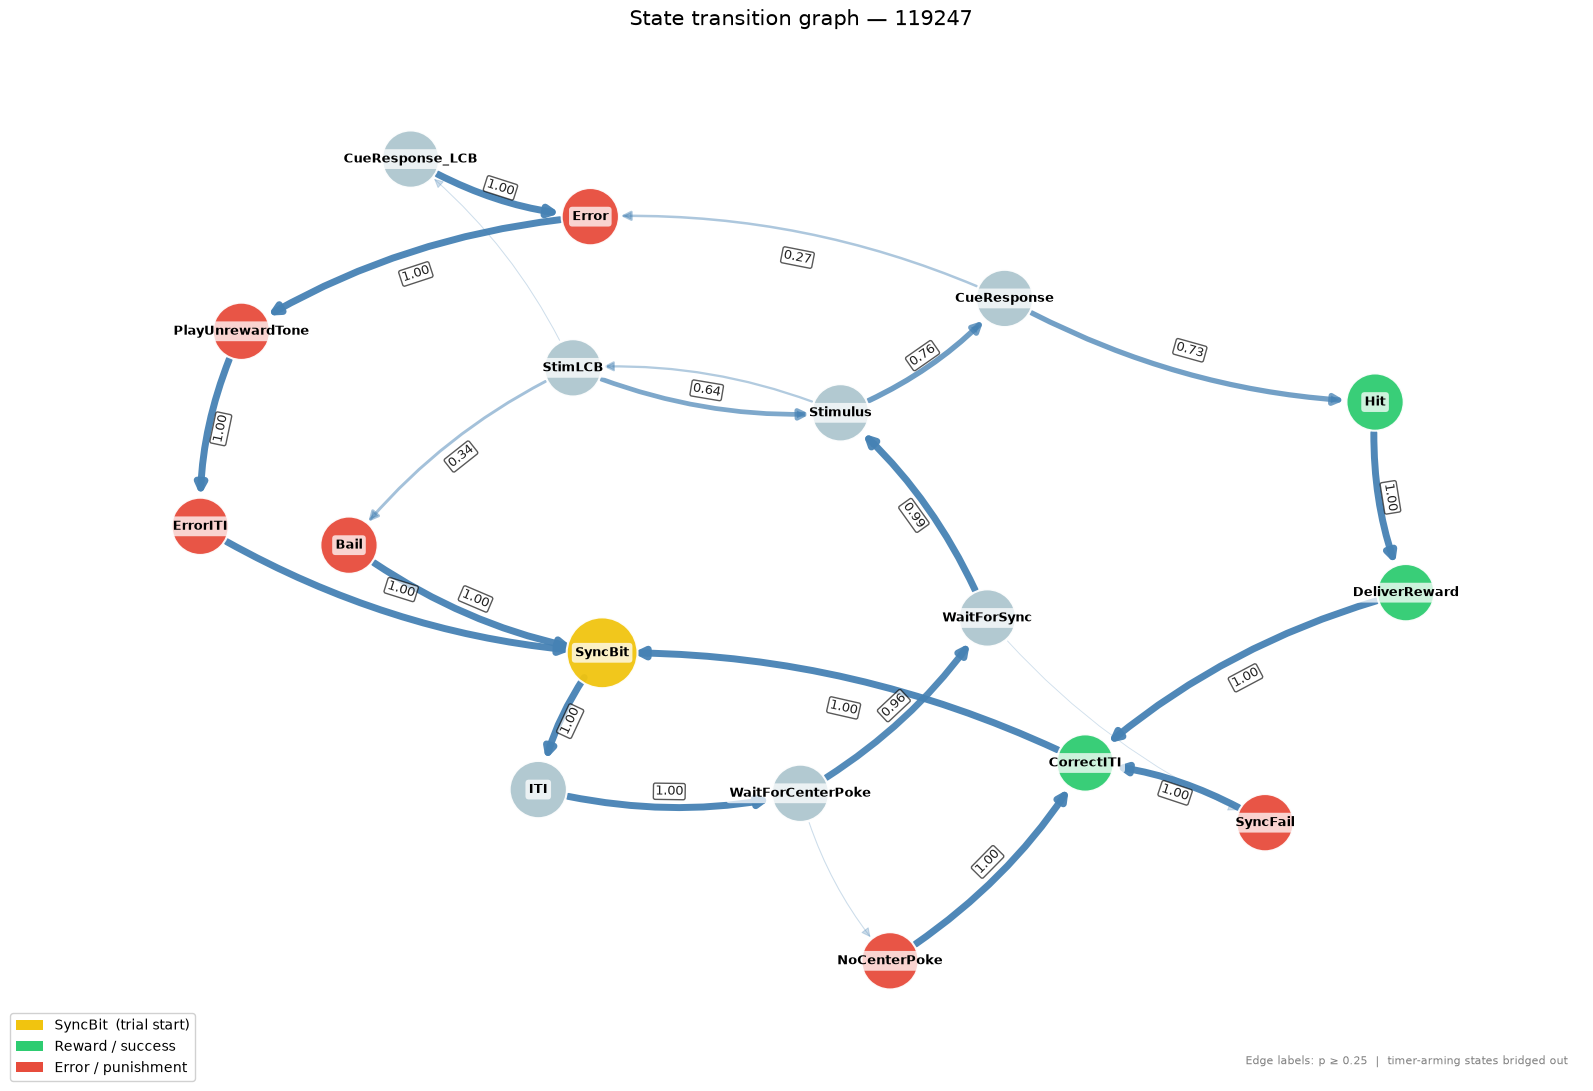

In [17]:
import networkx as nx
from matplotlib.patches import Patch

prob_df = state_transition_probability_df

# ── Semantic roles for this protocol ──────────────────────────────────────────
# Bpod state names are CamelCase, so match on the exact names rather than on
# lowercase keywords — "PlayUnrewardTone" contains "reward" but is an error state.
TRIAL_START   = "SyncBit"   # first state of all 165 trials
REWARD_STATES = {"Hit", "DeliverReward", "CorrectITI"}
ERROR_STATES  = {"Error", "ErrorITI", "PlayUnrewardTone", "NoResponse",
                 "NoCenterPoke", "SyncFail", "Bail"}

# ── Build base active matrix (drop all-zero rows/cols) ────────────────────────
mask   = (prob_df != 0).any(axis=1)
active = prob_df.loc[mask, prob_df.columns[(prob_df != 0).any(axis=0)]]

# ── Splice out the timer-arming states ────────────────────────────────────────
# StartStim, StartStimulusTimer and StartStimLCBTimer each last a single Bpod tick
# (1e-4 s) and exist only to arm a global timer — plumbing, not behavior.
#
# They are *bridged*, not merely deleted. Deleting the rows and columns outright
# would remove the WaitForCenterPoke -> StartStim -> WaitForSync path taken on 96%
# of trials and leave only the 6-trial NoCenterPoke failure edge, making the graph
# read as though the rat never poked. Absorbing them preserves path probability:
# for A -> D -> B with D dropped, the bridged edge A -> B carries p(A->D) * p(D->B).
labels = sorted(set(active.index) | set(active.columns))
P = active.reindex(index=labels, columns=labels).fillna(0.0)

drop_states = [s for s in labels if s.startswith("Start")]
keep_states = [s for s in labels if s not in drop_states]

if drop_states:
    P_kk = P.loc[keep_states, keep_states].to_numpy(float)
    P_kd = P.loc[keep_states, drop_states].to_numpy(float)
    P_dd = P.loc[drop_states, drop_states].to_numpy(float)
    P_dk = P.loc[drop_states, keep_states].to_numpy(float)
    # (I - P_dd)^-1 sums over paths of any length through the dropped states
    bridge = np.linalg.solve(np.eye(len(drop_states)) - P_dd, P_dk)
    filtered = pd.DataFrame(P_kk + P_kd @ bridge, index=keep_states, columns=keep_states)
else:
    filtered = P

filtered = filtered.loc[(filtered > 0).any(axis=1), filtered.columns[(filtered > 0).any(axis=0)]]

print(f"Bridged out : {drop_states}")
print(f"Remaining   : {filtered.index.tolist()}")

# ── Build directed graph ──────────────────────────────────────────────────────
G = nx.DiGraph()
for src in filtered.index:
    for dst in filtered.columns:
        prob = filtered.loc[src, dst]
        if prob > 0:
            G.add_edge(src, dst, weight=prob)

# ── Node colours by semantic role ─────────────────────────────────────────────
def node_color(name):
    if name == TRIAL_START:       return "#f1c40f"  # gold
    if name in REWARD_STATES:     return "#2ecc71"  # green
    if name in ERROR_STATES:      return "#e74c3c"  # red
    return "#aec6cf"                                # blue-grey

node_colors = [node_color(n) for n in G.nodes()]
node_sizes  = [2600 if n == TRIAL_START else 1700 for n in G.nodes()]

# ── Layout ────────────────────────────────────────────────────────────────────
try:
    pos = nx.kamada_kawai_layout(G, weight=None)
except Exception:
    pos = nx.spring_layout(G, seed=42, k=2.0)

# kamada_kawai can place two nodes almost on top of each other. Nudge apart any pair
# closer than MIN_SEP — only the topology carries meaning here, not the coordinates.
MIN_SEP = 0.20
nodes = list(G.nodes())
for _ in range(50):
    moved = False
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            a, b = np.asarray(pos[nodes[i]]), np.asarray(pos[nodes[j]])
            dist = np.linalg.norm(a - b)
            if dist < MIN_SEP:
                push = (a - b) / max(dist, 1e-9) * (MIN_SEP - dist) / 2
                pos[nodes[i]], pos[nodes[j]] = a + push, b - push
                moved = True
    if not moved:
        break

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 11))

# 1. Nodes first
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors, node_size=node_sizes,
    edgecolors="white", linewidths=1.5, alpha=0.95,
)

# 2. Edges — width and alpha scale with probability
all_weights = [d["weight"] for _, _, d in G.edges(data=True)]
max_w = max(all_weights) if all_weights else 1.0

for src, dst, data in G.edges(data=True):
    w = data["weight"]
    nx.draw_networkx_edges(
        G, pos, edgelist=[(src, dst)], ax=ax,
        width=0.6 + 4.4 * w / max_w,
        alpha=0.25 + 0.70 * w / max_w,
        edge_color="steelblue",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=14,
        connectionstyle="arc3,rad=0.12",
        min_source_margin=22,
        min_target_margin=22,
    )

# 3. Edge labels (dominant transitions only)
LABEL_THRESHOLD = 0.25
edge_labels = {
    (src, dst): f"{data['weight']:.2f}"
    for src, dst, data in G.edges(data=True)
    if data["weight"] >= LABEL_THRESHOLD
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, ax=ax,
    font_size=9, font_color="#222222",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.65),
)

# 4. Node labels LAST — drawn on top of everything with an opaque white backing
#    so edges passing through a node center cannot bleed into the text.
for node, (x, y) in pos.items():
    ax.text(
        x, y, node,
        ha="center", va="center",
        fontsize=9.5, fontweight="bold", color="black",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75),
        zorder=5,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor="#f1c40f", label=f"{TRIAL_START}  (trial start)"),
    Patch(facecolor="#2ecc71", label="Reward / success"),
    Patch(facecolor="#e74c3c", label="Error / punishment"),
    #Patch(facecolor="#aec6cf", label="Normal flow"),
]
ax.legend(handles=legend_elements, loc="lower left", bbox_to_anchor=(-0.01, -0.01),
          fontsize=10, framealpha=0.9)
ax.text(
    0.99, 0.01,
    f"Edge labels: p ≥ {LABEL_THRESHOLD}  |  timer-arming states bridged out",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="gray",
)
ax.set_title(f"State transition graph — {nwbfile.session_id}", fontsize=15, pad=12)
ax.margins(0.13)
ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
io.close()